Training base Random Forest pipeline...

Before Calibration
ROC-AUC: 0.739126
Brier Score: 0.197343

Calibrating model with sigmoid...

After Calibration
ROC-AUC: 0.739641
Brier Score: 0.069110

Calibration improved probability quality based on Brier Score.


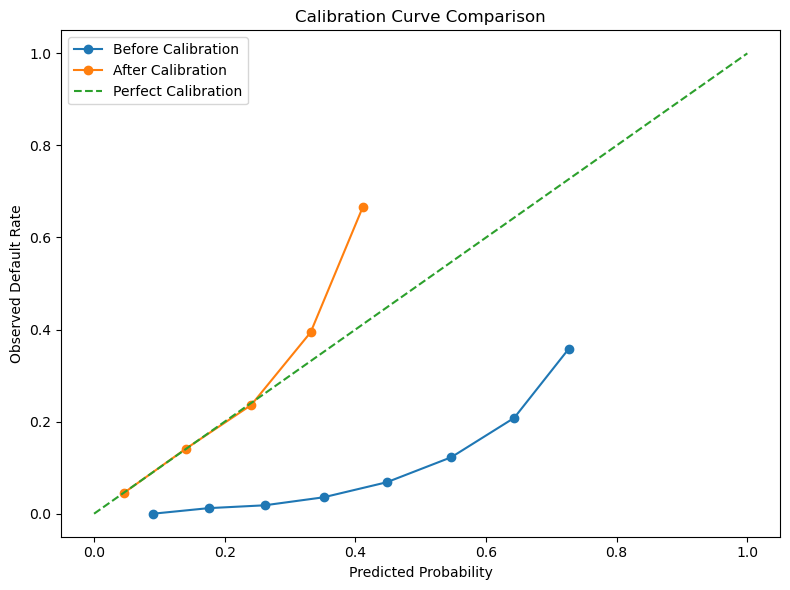


Saved files:
- ../models/random_forest_pipeline.joblib
- ../models/calibrated_random_forest.joblib
- ../reports/calibration_curve.png


In [2]:
import sys
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, brier_score_loss

from src.preprocess import (
    select_core_features,
    clean_features,
    build_preprocessor
)


def load_data(filepath="../data/home-credit-default-risk/application_train.csv"):
    df = pd.read_csv(filepath)
    df = select_core_features(df)
    df = clean_features(df)

    X = df.drop(columns=["TARGET"])
    y = df["TARGET"]

    return train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )


def build_random_forest_pipeline():
    return Pipeline([
        ("preprocess", build_preprocessor()),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ])


def plot_calibration_curves(y_val, y_prob_before, y_prob_after, save_path):
    prob_true_before, prob_pred_before = calibration_curve(
        y_val, y_prob_before, n_bins=10
    )
    prob_true_after, prob_pred_after = calibration_curve(
        y_val, y_prob_after, n_bins=10
    )

    plt.figure(figsize=(8, 6))
    plt.plot(prob_pred_before, prob_true_before, marker="o", label="Before Calibration")
    plt.plot(prob_pred_after, prob_true_after, marker="o", label="After Calibration")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Default Rate")
    plt.title("Calibration Curve Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


def main():
    os.makedirs("../models", exist_ok=True)
    os.makedirs("../reports", exist_ok=True)

    X_train, X_val, y_train, y_val = load_data()

    print("Training base Random Forest pipeline...")
    base_pipeline = build_random_forest_pipeline()
    base_pipeline.fit(X_train, y_train)

    y_prob_before = base_pipeline.predict_proba(X_val)[:, 1]
    auc_before = roc_auc_score(y_val, y_prob_before)
    brier_before = brier_score_loss(y_val, y_prob_before)

    print("\nBefore Calibration")
    print(f"ROC-AUC: {auc_before:.6f}")
    print(f"Brier Score: {brier_before:.6f}")

    print("\nCalibrating model with sigmoid...")
    calibrated_model = CalibratedClassifierCV(
        estimator=build_random_forest_pipeline(),
        method="sigmoid",
        cv=5
    )
    calibrated_model.fit(X_train, y_train)

    y_prob_after = calibrated_model.predict_proba(X_val)[:, 1]
    auc_after = roc_auc_score(y_val, y_prob_after)
    brier_after = brier_score_loss(y_val, y_prob_after)

    print("\nAfter Calibration")
    print(f"ROC-AUC: {auc_after:.6f}")
    print(f"Brier Score: {brier_after:.6f}")

    if brier_after < brier_before:
        print("\nCalibration improved probability quality based on Brier Score.")
    else:
        print("\nCalibration did not improve Brier Score. You may also try isotonic.")

    plot_calibration_curves(
        y_val,
        y_prob_before,
        y_prob_after,
        save_path="../reports/calibration_curve.png"
    )

    joblib.dump(base_pipeline, "../models/random_forest_pipeline.joblib")
    joblib.dump(calibrated_model, "../models/calibrated_random_forest.joblib")

    print("\nSaved files:")
    print("- ../models/random_forest_pipeline.joblib")
    print("- ../models/calibrated_random_forest.joblib")
    print("- ../reports/calibration_curve.png")


if __name__ == "__main__":
    main()